In [ ]:
#| hide
from randseq.core import *
import os
from randseq.example_data import get_example_data_dir

# randseq

> inferring restricted motifs using the  RandSeq method

## Installation

Install latest from the GitHub [repository][repo]:

```sh
$ pip install git+https://github.com/dbikard/randseq.git
```

[repo]: https://github.com/dbikard/randseq

[docs]: https://dbikard.github.io/randseq/

## Usage

In [ ]:
#| hide
data_path=get_example_data_dir()
os.listdir(data_path)

['__init__.py', 'countsTable.csv', '__pycache__']

In [ ]:
from randseq.core import find_restricted_motifs
from randseq.utils import calculate_log2fc
from randseq.example_data import get_example_data_dir
import pandas as pd

#Importing some example data
data_path=get_example_data_dir()
counts_file="countsTable.csv"
file_path=os.path.join(data_path,counts_file)
counts=pd.read_csv(file_path, index_col=0)
counts = counts[[col for col in counts.columns if ("_T0" in col) or ("MFDpir" in col)]]
left, right = "GTCCTAGGTATAATACTAGT", "GTTTTAGAGCTAGAAATAGC" #sequence context of the random library DNA

#Computing log2FC to reference sample
log2fc_df = calculate_log2fc(counts, reference_column='MFDpir', count_threshold=20, pseudocount=1)

#Running the pipeling
core_fixed_motifs_df, flexible_motifs_df = find_restricted_motifs(log2fc_df["JJ1886_T0"], 
                        left,
                        right, 
                        flexible_motif_patterns=[(6,0,0),(4,4,4),(3,4,4),(2,4,3),(3,5,4)],
                        )


--- Starting Fixed-Position Motif Analysis (on original short sequences) ---
Analyzing motifs of length 1 to 4, scanning positions 0 to 6 from each end, for JJ1886_T0.
Minimum sequence support for a motif: > 5 (i.e., 6 or more)
Found 2 core motifs at fixed positions:
  - Fixed Motif: GTG, Pos: 0, Len: 3, FracDep: 1.00, AvgFC: -4.76, N: 187
  - Fixed Motif: AAAG, Pos: 12, Len: 4, FracDep: 1.00, AvgFC: -5.08, N: 42

--- Starting Position-Independent Motif Analysis on Filtered Sequences (with context) ---
Filtered log2fc_series for flexible analysis: 11275 sequences remaining.
Looking for pattern: (6, 0, 0)
Looking for pattern: (4, 4, 4)
Looking for pattern: (3, 4, 4)
Looking for pattern: (2, 4, 3)
Looking for pattern: (3, 5, 4)

Identified 21 raw flexible motifs. Now filtering to core flexible motifs...
Found 5 core flexible motifs:
  - Flex Motif: GAGACC (from pattern (6, 0, 0)), FracDep: 1.00, AvgFC: -4.31, N: 9
  - Flex Motif: AACNNNNCTTT (from pattern (3, 4, 4)), FracDep: 1.00, AvgFC

In [ ]:
flexible_motifs_df

,motif,fraction_depleted,num_sequences,avg_log2fc,pattern
0,GAGACC,1.0,9,-4.313837,"(6, 0, 0)"
1,AACNNNNCTTT,1.0,21,-5.325198,"(3, 4, 4)"
2,CACNNNNGTAC,1.0,20,-5.237623,"(3, 4, 4)"
3,CACNNNNGTAT,1.0,5,-4.428066,"(3, 4, 4)"
4,GAGGNNNNGGTC,1.0,4,-4.357958,"(4, 4, 4)"


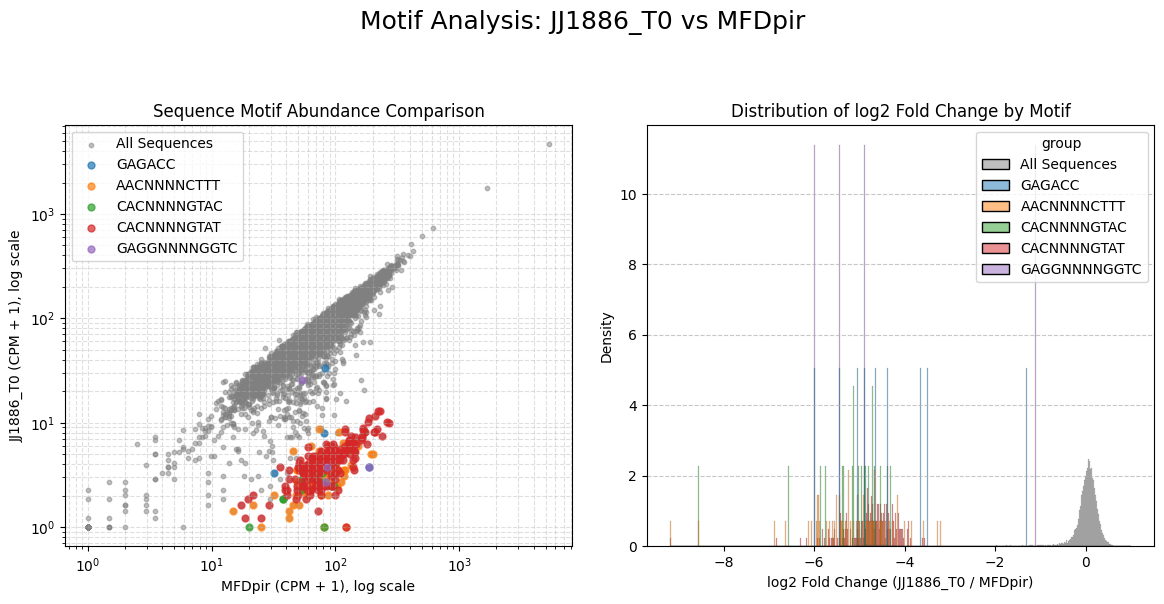

In [ ]:
from randseq.plotting import plot_motif_analysis
fig, axes = plot_motif_analysis(counts, "JJ1886_T0", "MFDpir", flexible_motifs_df, left, right)

## Documentation

Documentation can be found hosted on this GitHub [repository][repo]'s [pages][docs]. Additionally you can find package manager specific guidelines on [conda][conda] and [pypi][pypi] respectively.

[repo]: https://github.com/dbikard/randseq
[docs]: https://dbikard.github.io/randseq/
[pypi]: https://pypi.org/project/randseq/
[conda]: https://anaconda.org/dbikard/randseq

## Developer Guide

If you are new to using `nbdev` here are some useful pointers to get you started.

### Install randseq in Development mode

```sh
# make sure randseq package is installed in development mode
$ pip install -e .

# make changes under nbs/ directory
# ...

# compile to have changes apply to randseq
$ nbdev_prepare
```